# UpbitHack (EthereumHeist) — Preprocessing
**Project:** Temporal GNN + XAI for Anti-Money Laundering  
**Dataset:** UpbitHack from EthereumHeist (IEEE TIFS 2023) — 2.3M Ethereum transactions  

### Dataset Structure
| File | Rows | Key columns |
|---|---|---|
| `all-tx.csv` | 2,348,180 | hash, from, to, value, timeStamp, blockNumber, tokenSymbol, gasPrice, gasUsed, isError |
| `all-address.csv` | 577,313 | address, name_tag, label |
| `accounts-hacker.csv` | 18,746 | address, name_tag, label ← **illicit nodes** |

### Output
- `snapshots.pt` — 49 PyG snapshots, drop-in for Elliptic  
- `meta.json` — same keys as Elliptic meta.json  
- `scaler.pkl` — StandardScaler fitted on T1–T34  
- `snapshot_stats.csv` — per-snapshot stats  

### This notebook
1. Mount Drive & install dependencies
2. Upload UpbitHack CSVs
3. Load & inspect raw data
4. Clean transactions
5. Build node index + labels
6. Bin into 49 snapshots
7. Engineer 165 features (94 local + 71 neighbourhood)
8. Fit scaler on train (T1–T34), apply to all
9. Verification checks
10. Save outputs → Drive


---
## Cell 2 — Install Dependencies

In [2]:
import torch
import sys

torch_version = torch.__version__.split("+")[0]
cuda_tag      = "cu121" if torch.cuda.is_available() else "cpu"

!pip install -q torch-geometric
!pip install -q torch-scatter torch-sparse -f https://data.pyg.org/whl/torch-{torch_version}+{cuda_tag}.html
!pip install -q scikit-learn matplotlib seaborn

print("PyTorch  :", torch.__version__)
print("CUDA     :", torch.cuda.is_available())
print("Done.")


PyTorch  : 2.10.0+cu128
CUDA     : True
Done.


---
## Cell 3 — Upload UpbitHack CSVs

Upload the three files from your UpbitHack folder:  
- `all-tx.csv`  
- `all-address.csv`  
- `accounts-hacker.csv`  

> **Note:** `all-tx.csv` is ~500MB so it may take a few minutes.  
> Alternatively, if your UpbitHack folder is already in Google Drive, skip this cell and set `RAW_DIR` in Cell 4 to point to it.


---
## Cell 4 — Configuration

In [3]:
import os
from pathlib import Path

# ── Paths ────────────────────────────────────────────────────────────────
RAW_DIR = Path("/content/sample_data")                              # where CSVs are
PROCESSED_DIR = Path("/content/drive/MyDrive/Capstone/AML Code/data/processed_upbit")  # output
FIGURES_DIR   = Path("/content/drive/MyDrive/Capstone/AML Code/figures/upbit")          # plots

os.makedirs(PROCESSED_DIR, exist_ok=True)
os.makedirs(FIGURES_DIR,   exist_ok=True)

# ── Constants — match Elliptic exactly ───────────────────────────────────
NUM_FEATURES = 165    # must match EvolveGCN-H in_channels
LOCAL_DIM    = 94     # local node features  (feat_0  – feat_93)
NEIGH_DIM    = 71     # neighbourhood agg    (feat_94 – feat_164)
N_SNAPSHOTS  = 49
TRAIN_END    = 34     # T1  – T34
VAL_START    = 35
VAL_END      = 36     # T35 – T36
TEST_START   = 37     # T37 – T49
TEST_END     = 49
RANDOM_SEED  = 42
TOP_TOKENS   = ["USDT", "USDC", "WETH", "DAI"]

feature_cols = [f"feat_{i}" for i in range(NUM_FEATURES)]

import numpy as np, torch
np.random.seed(RANDOM_SEED)
torch.manual_seed(RANDOM_SEED)

def get_split(t):
    if t <= TRAIN_END: return "train"
    if t <= VAL_END:   return "val"
    return "test"

print("Config ready.")
print(f"  RAW_DIR       : {RAW_DIR}")
print(f"  PROCESSED_DIR : {PROCESSED_DIR}")


Config ready.
  RAW_DIR       : /content/sample_data
  PROCESSED_DIR : /content/drive/MyDrive/Capstone/AML Code/data/processed_upbit


---
## Cell 5 — Load Raw Data

In [4]:
import pandas as pd
import warnings
warnings.filterwarnings("ignore")

print("Loading CSVs (all-tx.csv is large, may take ~2 min)...")

tx   = pd.read_csv(RAW_DIR / "all-tx.csv",         low_memory=False)
addr = pd.read_csv(RAW_DIR / "all-address.csv",     low_memory=False)
hack = pd.read_csv(RAW_DIR / "accounts-hacker.csv", low_memory=False)

# Normalise addresses to lowercase
for df in [tx, addr, hack]:
    for col in ["address", "from", "to"]:
        if col in df.columns:
            df[col] = df[col].str.lower().str.strip()

print(f"  all-tx.csv       : {len(tx):,} rows  |  cols: {tx.columns.tolist()}")
print(f"  all-address.csv  : {len(addr):,} rows")
print(f"  accounts-hacker  : {len(hack):,} rows")
print()
print("Label breakdown (hacker file):")
print(hack["label"].value_counts().to_string())
print()
print("Top tokens:")
print(tx["tokenSymbol"].value_counts().head(8).to_string())


Loading CSVs (all-tx.csv is large, may take ~2 min)...
  all-tx.csv       : 2,348,180 rows  |  cols: ['hash', 'from', 'to', 'value', 'timeStamp', 'blockNumber', 'tokenSymbol', 'contractAddress', 'isError', 'gasPrice', 'gasUsed']
  all-address.csv  : 577,313 rows
  accounts-hacker  : 18,746 rows

Label breakdown (hacker file):
label
heist              16533
unknown service     1513
small value          700

Top tokens:
tokenSymbol
USDT      135738
POCC       28678
WETH       20633
USDC       19753
DAI        13178
SAC        12854
UNI-V2     12569
BWX         8457


---
## Cell 6 — Clean Transactions

In [5]:
before = len(tx)

tx["value"]       = pd.to_numeric(tx["value"],       errors="coerce").fillna(0).clip(lower=0)
tx["gasPrice"]    = pd.to_numeric(tx["gasPrice"],    errors="coerce").fillna(0).clip(lower=0)
tx["gasUsed"]     = pd.to_numeric(tx["gasUsed"],     errors="coerce").fillna(0).clip(lower=0)
tx["timeStamp"]   = pd.to_numeric(tx["timeStamp"],   errors="coerce")
tx["blockNumber"] = pd.to_numeric(tx["blockNumber"], errors="coerce")
tx["isError"]     = pd.to_numeric(tx["isError"],     errors="coerce").fillna(0)

# Drop error txs, missing fields, self-loops
tx = tx[tx["isError"] != 1].copy()
tx = tx.dropna(subset=["from", "to", "blockNumber", "timeStamp"])
tx = tx[tx["from"] != tx["to"]]

# Log-scale heavy numeric columns
tx["value_eth"]  = np.log1p(tx["value"]    / 1e18)
tx["gasPrice_n"] = np.log1p(tx["gasPrice"])
tx["gasUsed_n"]  = np.log1p(tx["gasUsed"])

GLOBAL_T0 = int(tx["timeStamp"].min())

print(f"Rows before cleaning : {before:,}")
print(f"Rows after  cleaning : {len(tx):,}  (dropped {before-len(tx):,})")
print(f"Global T0 (unix)     : {GLOBAL_T0}")

tx["timeStamp_dt"] = pd.to_datetime(tx["timeStamp"], unit="s")
print(f"Date range           : {tx["timeStamp_dt"].min().date()} → {tx["timeStamp_dt"].max().date()}")
print(f"Days span            : {(tx["timeStamp_dt"].max()-tx["timeStamp_dt"].min()).days}")


Rows before cleaning : 2,348,180
Rows after  cleaning : 2,318,459  (dropped 29,721)
Global T0 (unix)     : 1462814739
Date range           : 2016-05-09 → 2022-09-05
Days span            : 2309


---
## Cell 7 — Node Index & Labels

In [6]:
hacker_set    = set(hack["address"].dropna())
all_addresses = sorted(set(tx["from"].dropna()) | set(tx["to"].dropna()))
addr_to_idx   = {a: i for i, a in enumerate(all_addresses)}
N_NODES       = len(all_addresses)

# 1 = illicit (in accounts-hacker.csv), 0 = licit
global_labels = np.array(
    [1 if a in hacker_set else 0 for a in all_addresses], dtype=np.int64
)

# Address → label string for feature engineering
addr_label_map = dict(zip(addr["address"], addr["label"].fillna("").str.lower()))

illicit_total = global_labels.sum()
print(f"Total unique addresses : {N_NODES:,}")
print(f"Illicit nodes          : {illicit_total:,}  ({illicit_total/N_NODES*100:.1f}%)")
print(f"Licit nodes            : {N_NODES-illicit_total:,}  ({(N_NODES-illicit_total)/N_NODES*100:.1f}%)")
print(f"Class imbalance        : 1 : {(N_NODES-illicit_total)/illicit_total:.1f}  (illicit:licit)")


Total unique addresses : 577,555
Illicit nodes          : 18,738  (3.2%)
Licit nodes            : 558,817  (96.8%)
Class imbalance        : 1 : 29.8  (illicit:licit)


---
## Cell 8 — Bin into 49 Snapshots

In [7]:
block_min = int(tx["blockNumber"].min())
block_max = int(tx["blockNumber"].max())
bin_size  = max((block_max - block_min) // N_SNAPSHOTS, 1)

tx["snapshot"] = ((tx["blockNumber"] - block_min) // bin_size).clip(0, N_SNAPSHOTS - 1).astype(int)

snap_preview = tx.groupby("snapshot").agg(
    tx_count  = ("hash",    "count"),
    unique_from = ("from",  "nunique"),
).reset_index()

print(f"Block range      : {block_min:,} → {block_max:,}")
print(f"Bin size         : ~{bin_size:,} blocks per snapshot")
print(f"Non-empty snaps  : {len(snap_preview)} / {N_SNAPSHOTS}")
print(f"Tx per snap      : mean={snap_preview["tx_count"].mean():.0f}  "
      f"min={snap_preview["tx_count"].min()}  max={snap_preview["tx_count"].max():,}")


Block range      : 1,486,906 → 15,477,766
Bin size         : ~285,527 blocks per snapshot
Non-empty snaps  : 49 / 49
Tx per snap      : mean=47315  min=1  max=149,032


---
## Cell 9 — Feature Engineering Function

165 features structured to mirror Elliptic:
- **feat_0 – feat_93** (94): local node features computed directly from transactions
- **feat_94 – feat_164** (71): 1-hop neighbourhood aggregation (mean of local features over neighbours)


In [8]:
def compute_node_features(node, snap_tx, t_idx):
    """Return LOCAL_DIM (94) feature vector for one node in one snapshot."""
    out_tx = snap_tx[snap_tx["from"] == node]
    in_tx  = snap_tx[snap_tx["to"]   == node]
    all_tx = pd.concat([out_tx, in_tx], ignore_index=True)

    od, id_ = len(out_tx), len(in_tx)
    td = od + id_

    out_val = out_tx["value_eth"].sum()
    in_val  = in_tx["value_eth"].sum()
    net_val = out_val - in_val
    tot_val = out_val + in_val

    out_vm = out_tx["value_eth"].mean() if od > 0 else 0.0
    in_vm  = in_tx["value_eth"].mean()  if id_ > 0 else 0.0
    out_vs = out_tx["value_eth"].std()  if od > 1 else 0.0
    in_vs  = in_tx["value_eth"].std()   if id_ > 1 else 0.0
    out_vx = out_tx["value_eth"].max()  if od > 0 else 0.0
    in_vx  = in_tx["value_eth"].max()   if id_ > 0 else 0.0

    uniq_out = out_tx["to"].nunique()   if od > 0 else 0
    uniq_in  = in_tx["from"].nunique()  if id_ > 0 else 0

    gu_mean = all_tx["gasUsed_n"].mean()  if td > 0 else 0.0
    gu_sum  = all_tx["gasUsed_n"].sum()
    gu_std  = all_tx["gasUsed_n"].std()   if td > 1 else 0.0
    gp_mean = all_tx["gasPrice_n"].mean() if td > 0 else 0.0
    gp_std  = all_tx["gasPrice_n"].std()  if td > 1 else 0.0

    err_rate = all_tx["isError"].mean() if td > 0 else 0.0
    tok_div  = float(all_tx["tokenSymbol"].nunique()) if td > 0 else 0.0

    tok_vols = {tok: all_tx[all_tx["tokenSymbol"]==tok]["value_eth"].sum() for tok in TOP_TOKENS}
    other_vol = max(tot_val - sum(tok_vols.values()), 0.0)

    blk_span = float(all_tx["blockNumber"].max() - all_tx["blockNumber"].min()) if td > 1 else 0.0
    t_since  = float(np.log1p(max(all_tx["timeStamp"].min() - GLOBAL_T0, 0))) if td > 0 else 0.0
    snap_norm = t_idx / (N_SNAPSHOTS - 1)

    lbl = addr_label_map.get(node, "")
    is_heist    = float("heist"   in lbl)
    is_defi     = float("defi"    in lbl)
    is_exchange = float("exchange" in lbl)
    is_dex      = float("dex" in lbl or "uniswap" in lbl or "kyber" in lbl)
    is_tornado  = float("tornado" in lbl)
    is_erc20    = float("erc20"   in lbl or "erc721" in lbl)
    is_unk_svc  = float("unknown service" in lbl or "small value" in lbl)

    out_vel = (od / blk_span) if blk_span > 0 else 0.0
    in_vel  = (id_ / blk_span) if blk_span > 0 else 0.0

    core = np.array([
        float(od), float(id_), float(td),
        out_val, in_val, net_val, tot_val,
        out_vm, in_vm, out_vs, in_vs, out_vx, in_vx,
        float(uniq_out), float(uniq_in),
        gu_mean, gu_sum, gu_std, gp_mean, gp_std,
        err_rate, tok_div,
        tok_vols["USDT"], tok_vols["USDC"], tok_vols["WETH"], tok_vols["DAI"],
        other_vol, blk_span, t_since, snap_norm,
        is_heist, is_defi, is_exchange, is_dex, is_tornado,
        is_erc20, is_unk_svc, out_vel, in_vel,
    ], dtype=np.float32)   # 39 features

    feat = np.zeros(LOCAL_DIM, dtype=np.float32)
    feat[:len(core)] = core
    return feat

print("Feature function defined.")
print(f"  Local dim  : {LOCAL_DIM}  (feat_0 – feat_93)")
print(f"  Neigh dim  : {NEIGH_DIM}  (feat_94 – feat_164)")
print(f"  Total      : {NUM_FEATURES}")


Feature function defined.
  Local dim  : 94  (feat_0 – feat_93)
  Neigh dim  : 71  (feat_94 – feat_164)
  Total      : 165


---
## Cell 10 — Build 49 Snapshots

> This is the heavy cell — expect ~5–10 minutes on Colab.

In [10]:
from torch_geometric.data import Data

print("Precomputing global aggregations (runs once on full dataset)...")

# ── Precompute all node-level stats globally ──────────────────────────────
# This runs once on the full tx dataframe instead of inside the snapshot loop

# out stats
out_grp = tx.groupby(["snapshot", "from"])
in_grp  = tx.groupby(["snapshot", "to"])

print("  Computing degree and value stats...")
out_stats = out_grp.agg(
    out_deg     = ("value_eth", "count"),
    out_vsum    = ("value_eth", "sum"),
    out_vmean   = ("value_eth", "mean"),
    out_vstd    = ("value_eth", "std"),
    out_vmax    = ("value_eth", "max"),
    out_uniq    = ("to",        "nunique"),
).fillna(0).reset_index().rename(columns={"from": "address"})

in_stats = in_grp.agg(
    in_deg      = ("value_eth", "count"),
    in_vsum     = ("value_eth", "sum"),
    in_vmean    = ("value_eth", "mean"),
    in_vstd     = ("value_eth", "std"),
    in_vmax     = ("value_eth", "max"),
    in_uniq     = ("from",      "nunique"),
).fillna(0).reset_index().rename(columns={"to": "address"})

print("  Computing gas/error/token stats...")
# Combined (from + to perspective)
from_cols = tx[["snapshot","from","gasUsed_n","gasPrice_n","isError","tokenSymbol","blockNumber","timeStamp","value_eth"]].rename(columns={"from":"address"})
to_cols   = tx[["snapshot","to",  "gasUsed_n","gasPrice_n","isError","tokenSymbol","blockNumber","timeStamp","value_eth"]].rename(columns={"to":  "address"})
both      = pd.concat([from_cols, to_cols], ignore_index=True, copy=False)

both_grp  = both.groupby(["snapshot","address"])
misc_stats = both_grp.agg(
    gu_mean   = ("gasUsed_n",   "mean"),
    gu_sum    = ("gasUsed_n",   "sum"),
    gu_std    = ("gasUsed_n",   "std"),
    gp_mean   = ("gasPrice_n",  "mean"),
    gp_std    = ("gasPrice_n",  "std"),
    err_rate  = ("isError",     "mean"),
    tok_div   = ("tokenSymbol", "nunique"),
    blk_span  = ("blockNumber", lambda x: x.max()-x.min()),
    t_first   = ("timeStamp",   "min"),
    tot_val   = ("value_eth",   "sum"),
).fillna(0).reset_index()

print("  Computing per-token volumes...")
tok_stats_list = []
for tok in TOP_TOKENS:
    sub = both[both["tokenSymbol"]==tok].groupby(["snapshot","address"])["value_eth"].sum().reset_index()
    sub.columns = ["snapshot","address", f"vol_{tok}"]
    tok_stats_list.append(sub)

print("  Merging all stats...")
node_df = out_stats.merge(in_stats,   on=["snapshot","address"], how="outer")
node_df = node_df.merge(misc_stats,   on=["snapshot","address"], how="outer")
for ts in tok_stats_list:
    node_df = node_df.merge(ts,       on=["snapshot","address"], how="outer")
node_df = node_df.fillna(0)

node_df["net_val"]   = node_df["out_vsum"] - node_df["in_vsum"]
node_df["t_since"]   = np.log1p((node_df["t_first"] - GLOBAL_T0).clip(lower=0))
node_df["snap_norm"] = node_df["snapshot"] / (N_SNAPSHOTS - 1)
node_df["out_vel"]   = (node_df["out_deg"] / node_df["blk_span"].replace(0, np.nan)).fillna(0)
node_df["in_vel"]    = (node_df["in_deg"]  / node_df["blk_span"].replace(0, np.nan)).fillna(0)
other_vol_cols       = [f"vol_{t}" for t in TOP_TOKENS]
node_df["vol_other"] = (node_df["tot_val"] - node_df[other_vol_cols].sum(axis=1)).clip(lower=0)

# label flags
lbls = node_df["address"].map(lambda a: addr_label_map.get(a,""))
node_df["is_heist"]    = lbls.str.contains("heist").astype(float)
node_df["is_defi"]     = lbls.str.contains("defi").astype(float)
node_df["is_exchange"] = lbls.str.contains("exchange").astype(float)
node_df["is_dex"]      = lbls.str.contains("dex|uniswap|kyber").astype(float)
node_df["is_tornado"]  = lbls.str.contains("tornado").astype(float)
node_df["is_erc20"]    = lbls.str.contains("erc20|erc721").astype(float)
node_df["is_unk"]      = lbls.str.contains("unknown service|small value").astype(float)

# global label
node_df["label"]     = node_df["address"].map(lambda a: global_labels[addr_to_idx[a]] if a in addr_to_idx else 0).astype(np.int64)
node_df["node_idx"]  = node_df["address"].map(lambda a: addr_to_idx.get(a, 0))

FEAT_COLS = [
    "out_deg","in_deg","out_vsum","in_vsum","net_val","tot_val",
    "out_vmean","in_vmean","out_vstd","in_vstd","out_vmax","in_vmax",
    "out_uniq","in_uniq",
    "gu_mean","gu_sum","gu_std","gp_mean","gp_std",
    "err_rate","tok_div",
    "vol_USDT","vol_USDC","vol_WETH","vol_DAI","vol_other",
    "blk_span","t_since","snap_norm",
    "is_heist","is_defi","is_exchange","is_dex","is_tornado","is_erc20","is_unk",
    "out_vel","in_vel",
]  # 38 features → padded to LOCAL_DIM=94

print(f"  node_df shape: {node_df.shape}")
print("Global precomputation done.\n")

# ── Now build snapshots (fast — just slice node_df) ───────────────────────
snapshots    = []
build_stats  = []
train_feat_rows = []

# Precompute edge arrays per snapshot
print("Indexing edges per snapshot...")
tx_snap_grp = tx.groupby("snapshot")

print(f"Building {N_SNAPSHOTS} snapshots...")
print(f"{'T':>4}  {'Split':>5}  {'Nodes':>8}  {'Edges':>9}  {'Illicit':>8}  {'Illicit%':>9}")
print("-" * 55)

for t_idx in range(N_SNAPSHOTS):
    t     = t_idx + 1
    split = get_split(t)

    snap_nodes = node_df[node_df["snapshot"] == t_idx].copy()
    N = len(snap_nodes)

    if N == 0:
        snapshots.append(Data(
            x=torch.zeros((1, NUM_FEATURES), dtype=torch.float),
            edge_index=torch.zeros((2, 0), dtype=torch.long),
            y=torch.zeros(1, dtype=torch.long),
            train_mask=torch.tensor([split=="train"]),
            val_mask  =torch.tensor([split=="val"]),
            test_mask =torch.tensor([split=="test"]),
            time_step =torch.tensor(t, dtype=torch.long),
            tx_ids    =torch.zeros(1, dtype=torch.long),
            num_nodes =1,
        ))
        build_stats.append(dict(time_step=t, split=split, nodes=0,
                                edges=0, illicit_count=0, illicit_pct=0.0))
        continue

    snap_nodes = snap_nodes.reset_index(drop=True)
    local_idx  = {a: i for i, a in enumerate(snap_nodes["address"])}

    # ── Local features ────────────────────────────────────────────────
    local_feats = np.zeros((N, LOCAL_DIM), dtype=np.float32)
    vals = snap_nodes[FEAT_COLS].values.astype(np.float32)
    local_feats[:, :vals.shape[1]] = vals

    # ── Edges ─────────────────────────────────────────────────────────
    if t_idx in tx_snap_grp.groups:
        snap_tx   = tx_snap_grp.get_group(t_idx)
        valid     = snap_tx[snap_tx["from"].isin(local_idx) & snap_tx["to"].isin(local_idx)]
        src_arr   = valid["from"].map(local_idx).values.astype(np.int64)
        dst_arr   = valid["to"].map(local_idx).values.astype(np.int64)
        edge_index = torch.tensor(np.vstack([src_arr, dst_arr]), dtype=torch.long)
    else:
        src_arr    = np.array([], dtype=np.int64)
        dst_arr    = np.array([], dtype=np.int64)
        edge_index = torch.zeros((2, 0), dtype=torch.long)

    # ── Neighbourhood agg ─────────────────────────────────────────────
    neigh_sum   = np.zeros((N, NEIGH_DIM), dtype=np.float32)
    neigh_count = np.zeros(N, dtype=np.float32)
    if len(src_arr) > 0:
        np.add.at(neigh_sum,   src_arr, local_feats[dst_arr, :NEIGH_DIM])
        np.add.at(neigh_count, src_arr, 1)
        np.add.at(neigh_sum,   dst_arr, local_feats[src_arr, :NEIGH_DIM])
        np.add.at(neigh_count, dst_arr, 1)
    neigh_feats      = neigh_sum / neigh_count.clip(min=1)[:, None]
    node_feat_matrix = np.concatenate([local_feats, neigh_feats], axis=1)

    labels   = snap_nodes["label"].values.astype(np.int64)
    tx_ids_t = snap_nodes["node_idx"].values.astype(np.int64)

    data = Data(
        x          = torch.tensor(node_feat_matrix, dtype=torch.float),
        edge_index = edge_index,
        y          = torch.tensor(labels,   dtype=torch.long),
        train_mask = torch.tensor([split=="train"] * N, dtype=torch.bool),
        val_mask   = torch.tensor([split=="val"]   * N, dtype=torch.bool),
        test_mask  = torch.tensor([split=="test"]  * N, dtype=torch.bool),
        time_step  = torch.tensor(t,        dtype=torch.long),
        tx_ids     = torch.tensor(tx_ids_t, dtype=torch.long),
        num_nodes  = N,
    )
    snapshots.append(data)

    illicit_count = int(labels.sum())
    build_stats.append(dict(
        time_step=t, split=split, nodes=N,
        edges=edge_index.shape[1],
        illicit_count=illicit_count,
        illicit_pct=round(illicit_count/max(N,1)*100, 2),
    ))
    if t <= TRAIN_END:
        train_feat_rows.append(node_feat_matrix)

    if t in [1, 5, 10, 20, 30, 34, 35, 36, 37, 43, 49]:
        print(f"T{t:>2}  {split:>5}  {N:>8,}  {edge_index.shape[1]:>9,}  "
              f"{illicit_count:>8,}  {illicit_count/max(N,1)*100:>8.1f}%")

build_df = pd.DataFrame(build_stats)
print(f"\nAll {len(snapshots)} snapshots built successfully.")

Precomputing global aggregations (runs once on full dataset)...
  Computing degree and value stats...
  Computing gas/error/token stats...
  Computing per-token volumes...
  Merging all stats...
  node_df shape: (761448, 43)
Global precomputation done.

Indexing edges per snapshot...
Building 49 snapshots...
   T  Split     Nodes      Edges   Illicit   Illicit%
-------------------------------------------------------
T 1  train         6          6         2      33.3%
T 5  train        18         22         7      38.9%
T10  train    10,400     49,286       862       8.3%
T20  train     7,338     22,995     1,132      15.4%
T30  train    45,180    126,141     3,156       7.0%
T34  train    20,374     66,625     1,627       8.0%
T35    val    13,045     40,409     1,586      12.2%
T36    val    17,621     77,830     1,586       9.0%
T37   test    12,887     39,179     1,366      10.6%
T43   test     6,295     18,948       820      13.0%
T49   test     3,715     15,293       599      16.

---
## Cell 11 — Fit Scaler (Train Only) & Apply to All

In [11]:
from sklearn.preprocessing import StandardScaler

print("Fitting StandardScaler on T1–T34...")
train_feat_all = np.concatenate(train_feat_rows, axis=0)
scaler = StandardScaler()
scaler.fit(train_feat_all)

scaled_snapshots = []
for data in snapshots:
    x_sc = scaler.transform(data.x.numpy())
    x_sc = np.nan_to_num(x_sc, nan=0.0, posinf=0.0, neginf=0.0)
    scaled_snapshots.append(Data(
        x          = torch.tensor(x_sc, dtype=torch.float),
        edge_index = data.edge_index,
        y          = data.y,
        train_mask = data.train_mask,
        val_mask   = data.val_mask,
        test_mask  = data.test_mask,
        time_step  = data.time_step,
        tx_ids     = data.tx_ids,
        num_nodes  = data.num_nodes,
    ))

train_x = torch.cat([s.x for s in scaled_snapshots if s.time_step.item() <= TRAIN_END])
print(f"Post-scale mean (train, feat_0): {train_x[:,0].mean():.6f}  ← should be ~0")
print(f"Post-scale std  (train, feat_0): {train_x[:,0].std():.6f}   ← should be ~1")
print(f"NaN check: {torch.isnan(train_x).sum().item()} NaN values")


Fitting StandardScaler on T1–T34...
Post-scale mean (train, feat_0): -0.000000  ← should be ~0
Post-scale std  (train, feat_0): 1.000001   ← should be ~1
NaN check: 0 NaN values


---
## Cell 12 — Verification Checks

In [12]:
print("VERIFICATION CHECKS")
print("=" * 55)
all_passed = True

# Check 1: feature dimension
wrong_dim = [s.time_step.item() for s in scaled_snapshots if s.x.shape[1] != NUM_FEATURES]
ok = len(wrong_dim) == 0
print(f"Check 1 — Feature dim={NUM_FEATURES}      : {"✓ PASS" if ok else f"✗ FAIL {wrong_dim}"}")
if not ok: all_passed = False

# Check 2: no NaN
nan_snaps = [s.time_step.item() for s in scaled_snapshots if torch.isnan(s.x).any()]
ok = len(nan_snaps) == 0
print(f"Check 2 — No NaN values       : {"✓ PASS" if ok else f"✗ FAIL {nan_snaps}"}")
if not ok: all_passed = False

# Check 3: edge index bounds
bad_edges = [s.time_step.item() for s in scaled_snapshots
             if s.edge_index.shape[1] > 0 and s.edge_index.max() >= s.num_nodes]
ok = len(bad_edges) == 0
print(f"Check 3 — Edge index bounds   : {"✓ PASS" if ok else f"✗ FAIL {bad_edges}"}")
if not ok: all_passed = False

# Check 4: binary labels
bad_labels = [s.time_step.item() for s in scaled_snapshots
              if not set(s.y.unique().tolist()).issubset({0,1})]
ok = len(bad_labels) == 0
print(f"Check 4 — Binary labels (0/1) : {"✓ PASS" if ok else f"✗ FAIL {bad_labels}"}")
if not ok: all_passed = False

# Check 5: 49 snapshots
ok = len(scaled_snapshots) == 49
print(f"Check 5 — 49 snapshots built  : {"✓ PASS" if ok else f"✗ FAIL got {len(scaled_snapshots)}"}")
if not ok: all_passed = False

# Check 6: no train/test node leakage
train_ids, test_ids = set(), set()
for s in scaled_snapshots:
    t = s.time_step.item()
    ids = set(s.tx_ids.tolist())
    if t <= TRAIN_END:    train_ids.update(ids)
    elif t >= TEST_START: test_ids.update(ids)
overlap = train_ids & test_ids
ok = len(overlap) == 0
print(f"Check 6 — No train/test leak  : {"✓ PASS" if ok else f"✗ NOTE: {len(overlap)} addresses appear in both splits (expected for Ethereum — same address can transact across time)"}")

print()
print("=" * 55)
print(f"OVERALL : {"✓ ALL CHECKS PASSED" if all_passed else "✗ CHECK FAILURES ABOVE"}")


VERIFICATION CHECKS
Check 1 — Feature dim=165      : ✓ PASS
Check 2 — No NaN values       : ✓ PASS
Check 3 — Edge index bounds   : ✓ PASS
Check 4 — Binary labels (0/1) : ✓ PASS
Check 5 — 49 snapshots built  : ✓ PASS
Check 6 — No train/test leak  : ✗ NOTE: 8128 addresses appear in both splits (expected for Ethereum — same address can transact across time)

OVERALL : ✓ ALL CHECKS PASSED


---
## Cell 13 — Snapshot Overview Plot

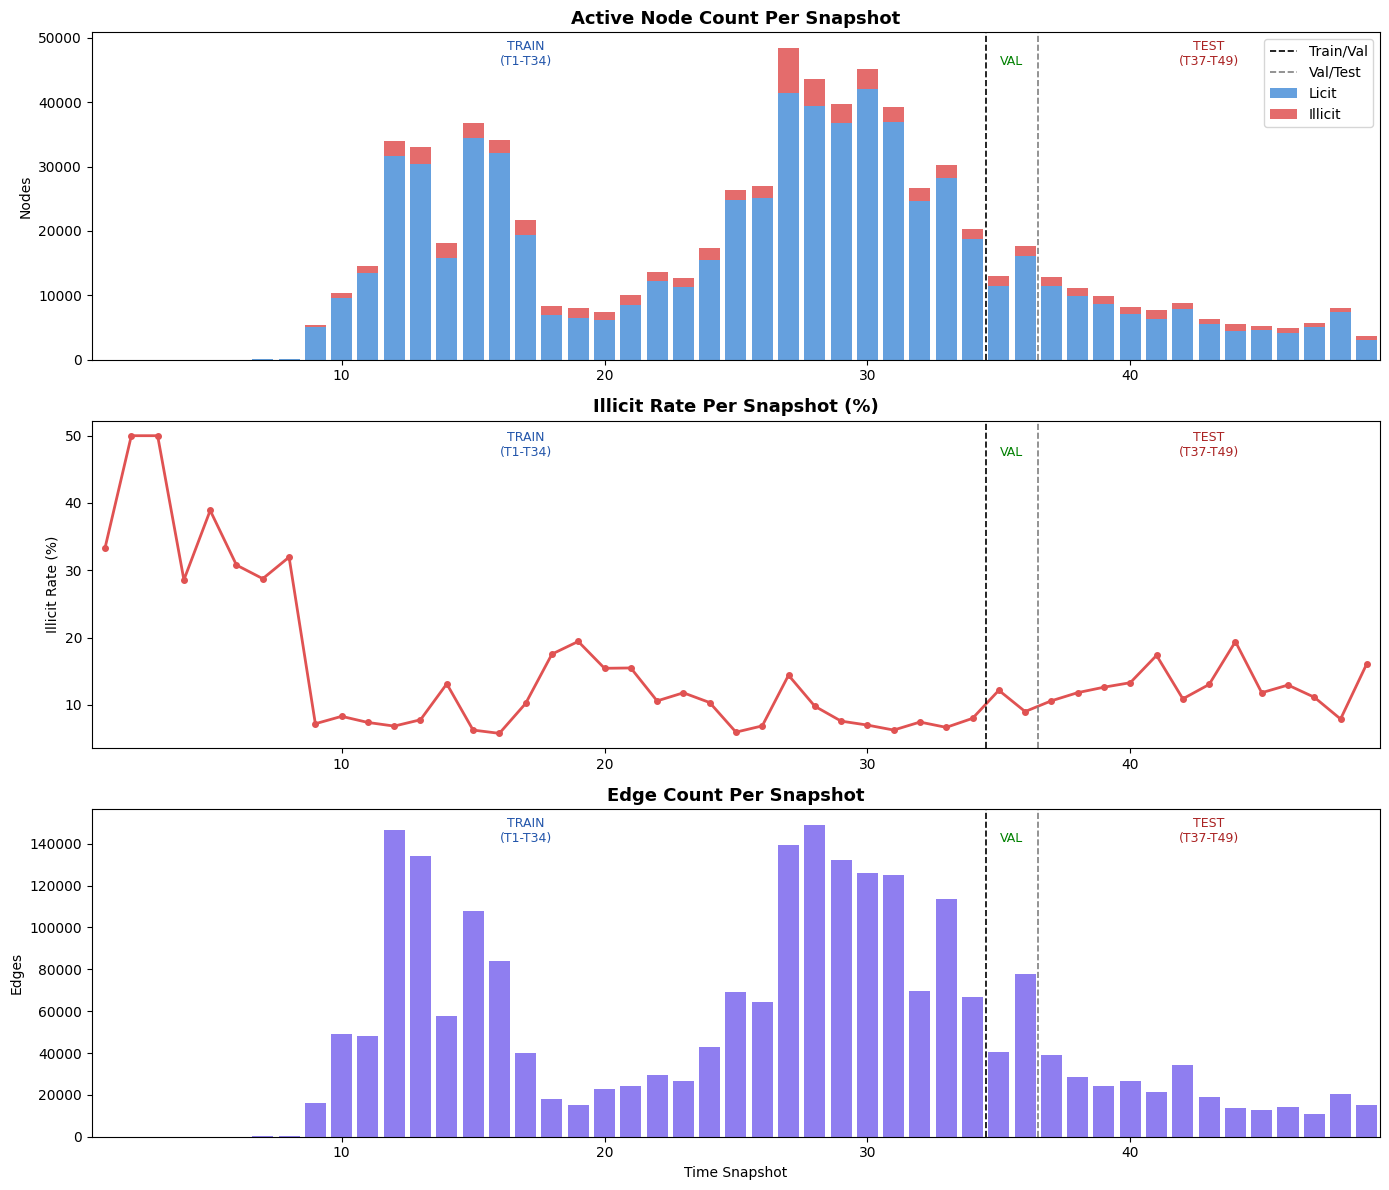

Saved → figures/01_upbit_snapshot_overview.png


In [15]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

fig, axes = plt.subplots(3, 1, figsize=(14, 12))
ts = build_df["time_step"]

# Panel 1: node counts
licit_counts   = build_df["nodes"] - build_df["illicit_count"]
axes[0].bar(ts, licit_counts,           label="Licit",   color="#4A90D9", alpha=0.85)
axes[0].bar(ts, build_df["illicit_count"], bottom=licit_counts,
            label="Illicit", color="#E05252", alpha=0.85)
axes[0].axvline(x=34.5, color="black", linestyle="--", linewidth=1.2, label="Train/Val")
axes[0].axvline(x=36.5, color="gray",  linestyle="--", linewidth=1.2, label="Val/Test")
axes[0].set_title("Active Node Count Per Snapshot", fontsize=13, fontweight="bold")
axes[0].set_ylabel("Nodes")
axes[0].legend(loc="upper right")

# Panel 2: illicit rate
axes[1].plot(ts, build_df["illicit_pct"], color="#E05252", linewidth=2, marker="o", markersize=4)
axes[1].axvline(x=34.5, color="black", linestyle="--", linewidth=1.2)
axes[1].axvline(x=36.5, color="gray",  linestyle="--", linewidth=1.2)
axes[1].set_title("Illicit Rate Per Snapshot (%)", fontsize=13, fontweight="bold")
axes[1].set_ylabel("Illicit Rate (%)")

# Panel 3: edge count
axes[2].bar(ts, build_df["edges"], color="#7B68EE", alpha=0.85)
axes[2].axvline(x=34.5, color="black", linestyle="--", linewidth=1.2)
axes[2].axvline(x=36.5, color="gray",  linestyle="--", linewidth=1.2)
axes[2].set_title("Edge Count Per Snapshot", fontsize=13, fontweight="bold")
axes[2].set_ylabel("Edges")
axes[2].set_xlabel("Time Snapshot")

for ax in axes:
    ymax = ax.get_ylim()[1]
    ax.text(17,   ymax*0.9, "TRAIN\n(T1-T34)",  ha="center", fontsize=9, color="#2255AA")
    ax.text(35.5, ymax*0.9, "VAL",              ha="center", fontsize=9, color="green")
    ax.text(43,   ymax*0.9, "TEST\n(T37-T49)",  ha="center", fontsize=9, color="#AA2222")
    ax.set_xlim(0.5, 49.5)

plt.tight_layout()
fig.savefig(FIGURES_DIR / "01_upbit_snapshot_overview.png", bbox_inches="tight")
plt.show()
print("Saved → figures/01_upbit_snapshot_overview.png")


---
## Cell 14 — Save All Outputs

In [17]:
import json, pickle

# snapshots.pt
snaps_path = PROCESSED_DIR / "snapshots.pt"
torch.save(scaled_snapshots, snaps_path)
print(f"✓ snapshots.pt       → {snaps_path}")

# scaler.pkl
scaler_path = PROCESSED_DIR / "scaler.pkl"
with open(scaler_path, "wb") as f:
    pickle.dump(scaler, f)
print(f"✓ scaler.pkl         → {scaler_path}")

# snapshot_stats.csv
stats_path = PROCESSED_DIR / "snapshot_stats.csv"
build_df.to_csv(stats_path, index=False)
print(f"✓ snapshot_stats.csv → {stats_path}")

# meta.json
train_rows = build_df[build_df["time_step"] <= TRAIN_END]
meta = {
    "num_snapshots":        len(scaled_snapshots),
    "num_features":         NUM_FEATURES,
    "feature_cols":         f"feat_0 to feat_{NUM_FEATURES-1}",
    "local_features":       f"feat_0 to feat_{LOCAL_DIM-1} ({LOCAL_DIM} features)",
    "aggregated_features":  f"feat_{LOCAL_DIM} to feat_{NUM_FEATURES-1} ({NEIGH_DIM} features)",
    "total_nodes":          int(build_df["nodes"].sum()),
    "total_edges":          int(build_df["edges"].sum()),
    "total_illicit":        int(build_df["illicit_count"].sum()),
    "overall_illicit_pct":  round(build_df["illicit_count"].sum() /
                                  max(build_df["nodes"].sum(), 1) * 100, 3),
    "train_snapshots":      f"T1–T{TRAIN_END}",
    "val_snapshots":        f"T{VAL_START}–T{VAL_END}",
    "test_snapshots":       f"T{TEST_START}–T{TEST_END}",
    "label_mapping":        {"0": "licit", "1": "illicit"},
    "scaler":               f"StandardScaler fitted on T1–T{TRAIN_END} only",
    "class_imbalance_train": f"1:{round(train_rows['nodes'].sum() / max(train_rows['illicit_count'].sum(),1), 1)} (illicit:licit)",
    "features_anonymized":  False,
    "source":               "UpbitHack — EthereumHeist (IEEE TIFS 2023)",
    "note":                 f"{NUM_FEATURES} engineered features: {LOCAL_DIM} local + {NEIGH_DIM} 1-hop neighbourhood agg",
}
meta_path = PROCESSED_DIR / "meta.json"
with open(meta_path, "w") as f:
    json.dump(meta, f, indent=2)
print(f"✓ meta.json          → {meta_path}")

print()
print("=" * 60)
print("  DATASET SUMMARY")
print("=" * 60)
for k, v in meta.items():
    print(f"  {k:<28} {v}")

print()
print("=" * 60)
print("  NEXT STEPS")
print("=" * 60)
print("  In 05_evolvegcn_h_training_fixed.ipynb change only:")
print(f"    DATA_PATH = Path('{snaps_path}')")
print(f"    META_PATH = Path('{meta_path}')")
print("  in_channels=165 stays the same — no model changes needed.")


✓ snapshots.pt       → /content/drive/MyDrive/Capstone/AML Code/data/processed_upbit/snapshots.pt
✓ scaler.pkl         → /content/drive/MyDrive/Capstone/AML Code/data/processed_upbit/scaler.pkl
✓ snapshot_stats.csv → /content/drive/MyDrive/Capstone/AML Code/data/processed_upbit/snapshot_stats.csv
✓ meta.json          → /content/drive/MyDrive/Capstone/AML Code/data/processed_upbit/meta.json

  DATASET SUMMARY
  num_snapshots                49
  num_features                 165
  feature_cols                 feat_0 to feat_164
  local_features               feat_0 to feat_93 (94 features)
  aggregated_features          feat_94 to feat_164 (71 features)
  total_nodes                  761448
  total_edges                  2318459
  total_illicit                71033
  overall_illicit_pct          9.329
  train_snapshots              T1–T34
  val_snapshots                T35–T36
  test_snapshots               T37–T49
  label_mapping                {'0': 'licit', '1': 'illicit'}
  scaler    

---
## Cell 15 — Reload Test

In [18]:
print("LOAD TEST — verifying saved files reload correctly")
print("=" * 55)

loaded_snaps = torch.load(snaps_path, weights_only=False)
print(f"✓ snapshots.pt  : {len(loaded_snaps)} snapshots")

with open(scaler_path, "rb") as f:
    loaded_scaler = pickle.load(f)
print(f"✓ scaler.pkl    : {type(loaded_scaler).__name__}")

with open(meta_path, "r") as f:
    loaded_meta = json.load(f)
print(f"✓ meta.json     : {len(loaded_meta)} fields")

s1  = loaded_snaps[0]
s49 = loaded_snaps[-1]

print()
print(f"First snapshot  (T{s1.time_step.item()}):")
print(f"  x.shape      : {s1.x.shape}  ← should be (N, {NUM_FEATURES})")
print(f"  edge_index   : {s1.edge_index.shape}")
print(f"  illicit      : {s1.y.sum().item()}")

print()
print(f"Last snapshot   (T{s49.time_step.item()}):")
print(f"  x.shape      : {s49.x.shape}")
print(f"  edge_index   : {s49.edge_index.shape}")
print(f"  illicit      : {s49.y.sum().item()}")

print()
print("=" * 55)
print("PREPROCESSING COMPLETE — ready for EvolveGCN-H training")


LOAD TEST — verifying saved files reload correctly
✓ snapshots.pt  : 49 snapshots
✓ scaler.pkl    : StandardScaler
✓ meta.json     : 18 fields

First snapshot  (T1):
  x.shape      : torch.Size([6, 165])  ← should be (N, 165)
  edge_index   : torch.Size([2, 6])
  illicit      : 2

Last snapshot   (T49):
  x.shape      : torch.Size([3715, 165])
  edge_index   : torch.Size([2, 15293])
  illicit      : 599

PREPROCESSING COMPLETE — ready for EvolveGCN-H training
